In [3]:
import sys
from matplotlib import pyplot
from keras.datasets import cifar10
from keras.utils import to_categorical
from keras.layers import Conv2D, Flatten, Dense, BatchNormalization, MaxPooling2D, Dropout
from keras.models import Sequential
from keras.optimizers import SGD
import tensorflow as tf
from tensorflow.keras import layers

In [4]:
## carregando conjunto dos dados de treino e teste
def load_dataset():
  (trainX,trainY),(testX,testY) = cifar10.load_data()
  trainY = to_categorical(trainY)
  testY = to_categorical(testY)
  return trainX, trainY, testX, testY

# normalizando as imagens
def prep_pixels(train,test):
  train_norm = train.astype('float32')
  test_norm = test.astype('float32')
  train_norm = train_norm/255.0
  test_norm = test_norm/255.0
  return train_norm, test_norm

In [5]:
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
])

In [7]:
def define_model():
  model = Sequential()
  data_augmentation,
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  model.add(Conv2D(32,(3,3), activation='relu', kernel_initializer = 'he_uniform', padding = "same", input_shape = (32, 32, 3) ))
  model.add(Conv2D(32,(3,3), activation='relu', kernel_initializer = 'he_uniform', padding = "same"))
  model.add(BatchNormalization())
  model.add(MaxPooling2D((2,2)))
  model.add(Dropout((0.2), noise_shape = None))
  model.add(Conv2D(64,(3,3), activation='relu', kernel_initializer='he_uniform', padding='same'))
  model.add(Conv2D(64,(3,3), activation='relu', kernel_initializer='he_uniform', padding='same'))
  model.add(BatchNormalization())
  model.add(MaxPooling2D((2,2)))
  model.add(Dropout((0.2), noise_shape = None))
  model.add(Conv2D(128, (3,3), activation = 'relu', kernel_initializer= 'he_uniform', padding = "same"))
  model.add(Conv2D(128, (3,3), activation = 'relu', kernel_initializer= 'he_uniform', padding = "same"))
  model.add(BatchNormalization())
  model.add(MaxPooling2D((2,2)))
  model.add(Dropout((0.2), noise_shape = None))
  model.add(Flatten())
  model.add(Dense(128, activation='relu', kernel_initializer='he_uniform'))
  model.add(BatchNormalization())
  model.add(Dropout((0.2), noise_shape = None))
  model.add(Dense(10, activation='softmax'))
  opt = SGD(learning_rate=0.001, momentum=0.9)
  model.compile(optimizer = opt, loss= 'categorical_crossentropy', metrics = ['accuracy'])
  return model
  

In [8]:
def summarize_diagnostics(history):
  ## plot loss
  pyplot.subplot(211)
  pyplot.title('Cross Entropy Loss')
  pyplot.plot(history.history['loss'], color = 'blue', label = 'train')
  pyplot.plot(history.history['val_loss'], color = 'orange', label = 'test')
  ## plot acuracia
  pyplot.subplot(212)
  pyplot.title('Classification Accuracy')
  pyplot.plot(history.history['accuracy'], color = 'blue', label = 'train')
  pyplot.plot(history.history['val_accuracy'], color = 'orange', label = 'test')
  pyplot.show()

> 83.580


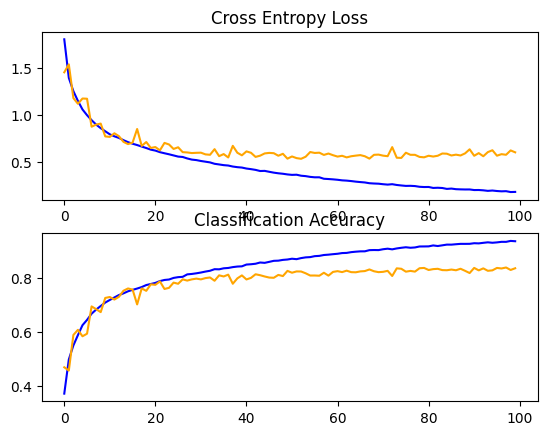

In [10]:
def run_test_harness():
  trainX, trainY, testX, testY = load_dataset()
  trainX, testX = prep_pixels(trainX, testX)
  model = define_model()
  history = model.fit(trainX, trainY, epochs = 100, batch_size = 64, validation_data = (testX, testY), verbose = 0)
  _, acc = model.evaluate(testX, testY, verbose = 0)
  print('> %.3f' % (acc*100.0))
  summarize_diagnostics(history)

run_test_harness()

https://www.tensorflow.org/tutorials/images/data_augmentation?hl=pt-br